In [1]:
import MDAnalysis as mda
from matplotlib import pyplot as plt
from MDAnalysis.analysis import contacts
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
# suppress some MDAnalysis warnings about PSF files
warnings.filterwarnings('ignore')
from MDAnalysis.analysis import distances

d:\anaconda\envs\mdanalysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
xtc_file = ["E:/a40/a40/200_700.xtc","E:/a40/a40p8/200_750.xtc","E:/a40/a40p26/200_700.xtc"]
gro_file = ["E:/a40/a40/md_p.gro","E:/a40/a40p8/md_p.gro","E:/a40/a40p26/md_p.gro"]
png = ["E:/a40/cont_a40.png","E:/a40/cont_a40p8.png" ,"E:/a40/cont_a40p26.png" ]
txt = ["E:/a40/cont_a40.txt","E:/a40/cont_a40p8.txt" ,"E:/a40/cont_a40p26.txt"]

In [ ]:
def contact_prob(u, radius=8,start=20000):
    """
    计算轨迹中每一帧的接触矩阵，并计算接触矩阵的平均值。

    参数：
    - u: MDAnalysis的Universe对象，包含轨迹和结构数据。
    - radius: 接触的距离阈值（单位为Å），默认为8.0 Å。

    返回：
    - avg_cont: 所有轨迹帧的接触矩阵的平均值。
    """
    timeseries = []
    ca_atoms = u.select_atoms('not (name H* or backbone)')  # 选择CA原子

    # 遍历轨迹中的每一帧
    for ts in u.trajectory[start:]:
        # 计算每对CA原子之间的距离矩阵
        dist = distances.distance_array(ca_atoms.positions, ca_atoms.positions, box=u.dimensions)
        
        # 计算接触矩阵（假设接触阈值为radius）
        contact_matrix = (dist <= radius).astype(int)
        
        # 将当前帧的接触矩阵和帧编号添加到timeseries列表
        timeseries.append([ts.frame, contact_matrix])

    # 计算接触矩阵的平均值
    avg_cont = np.mean([x[1] for x in timeseries], axis=0)

    return avg_cont

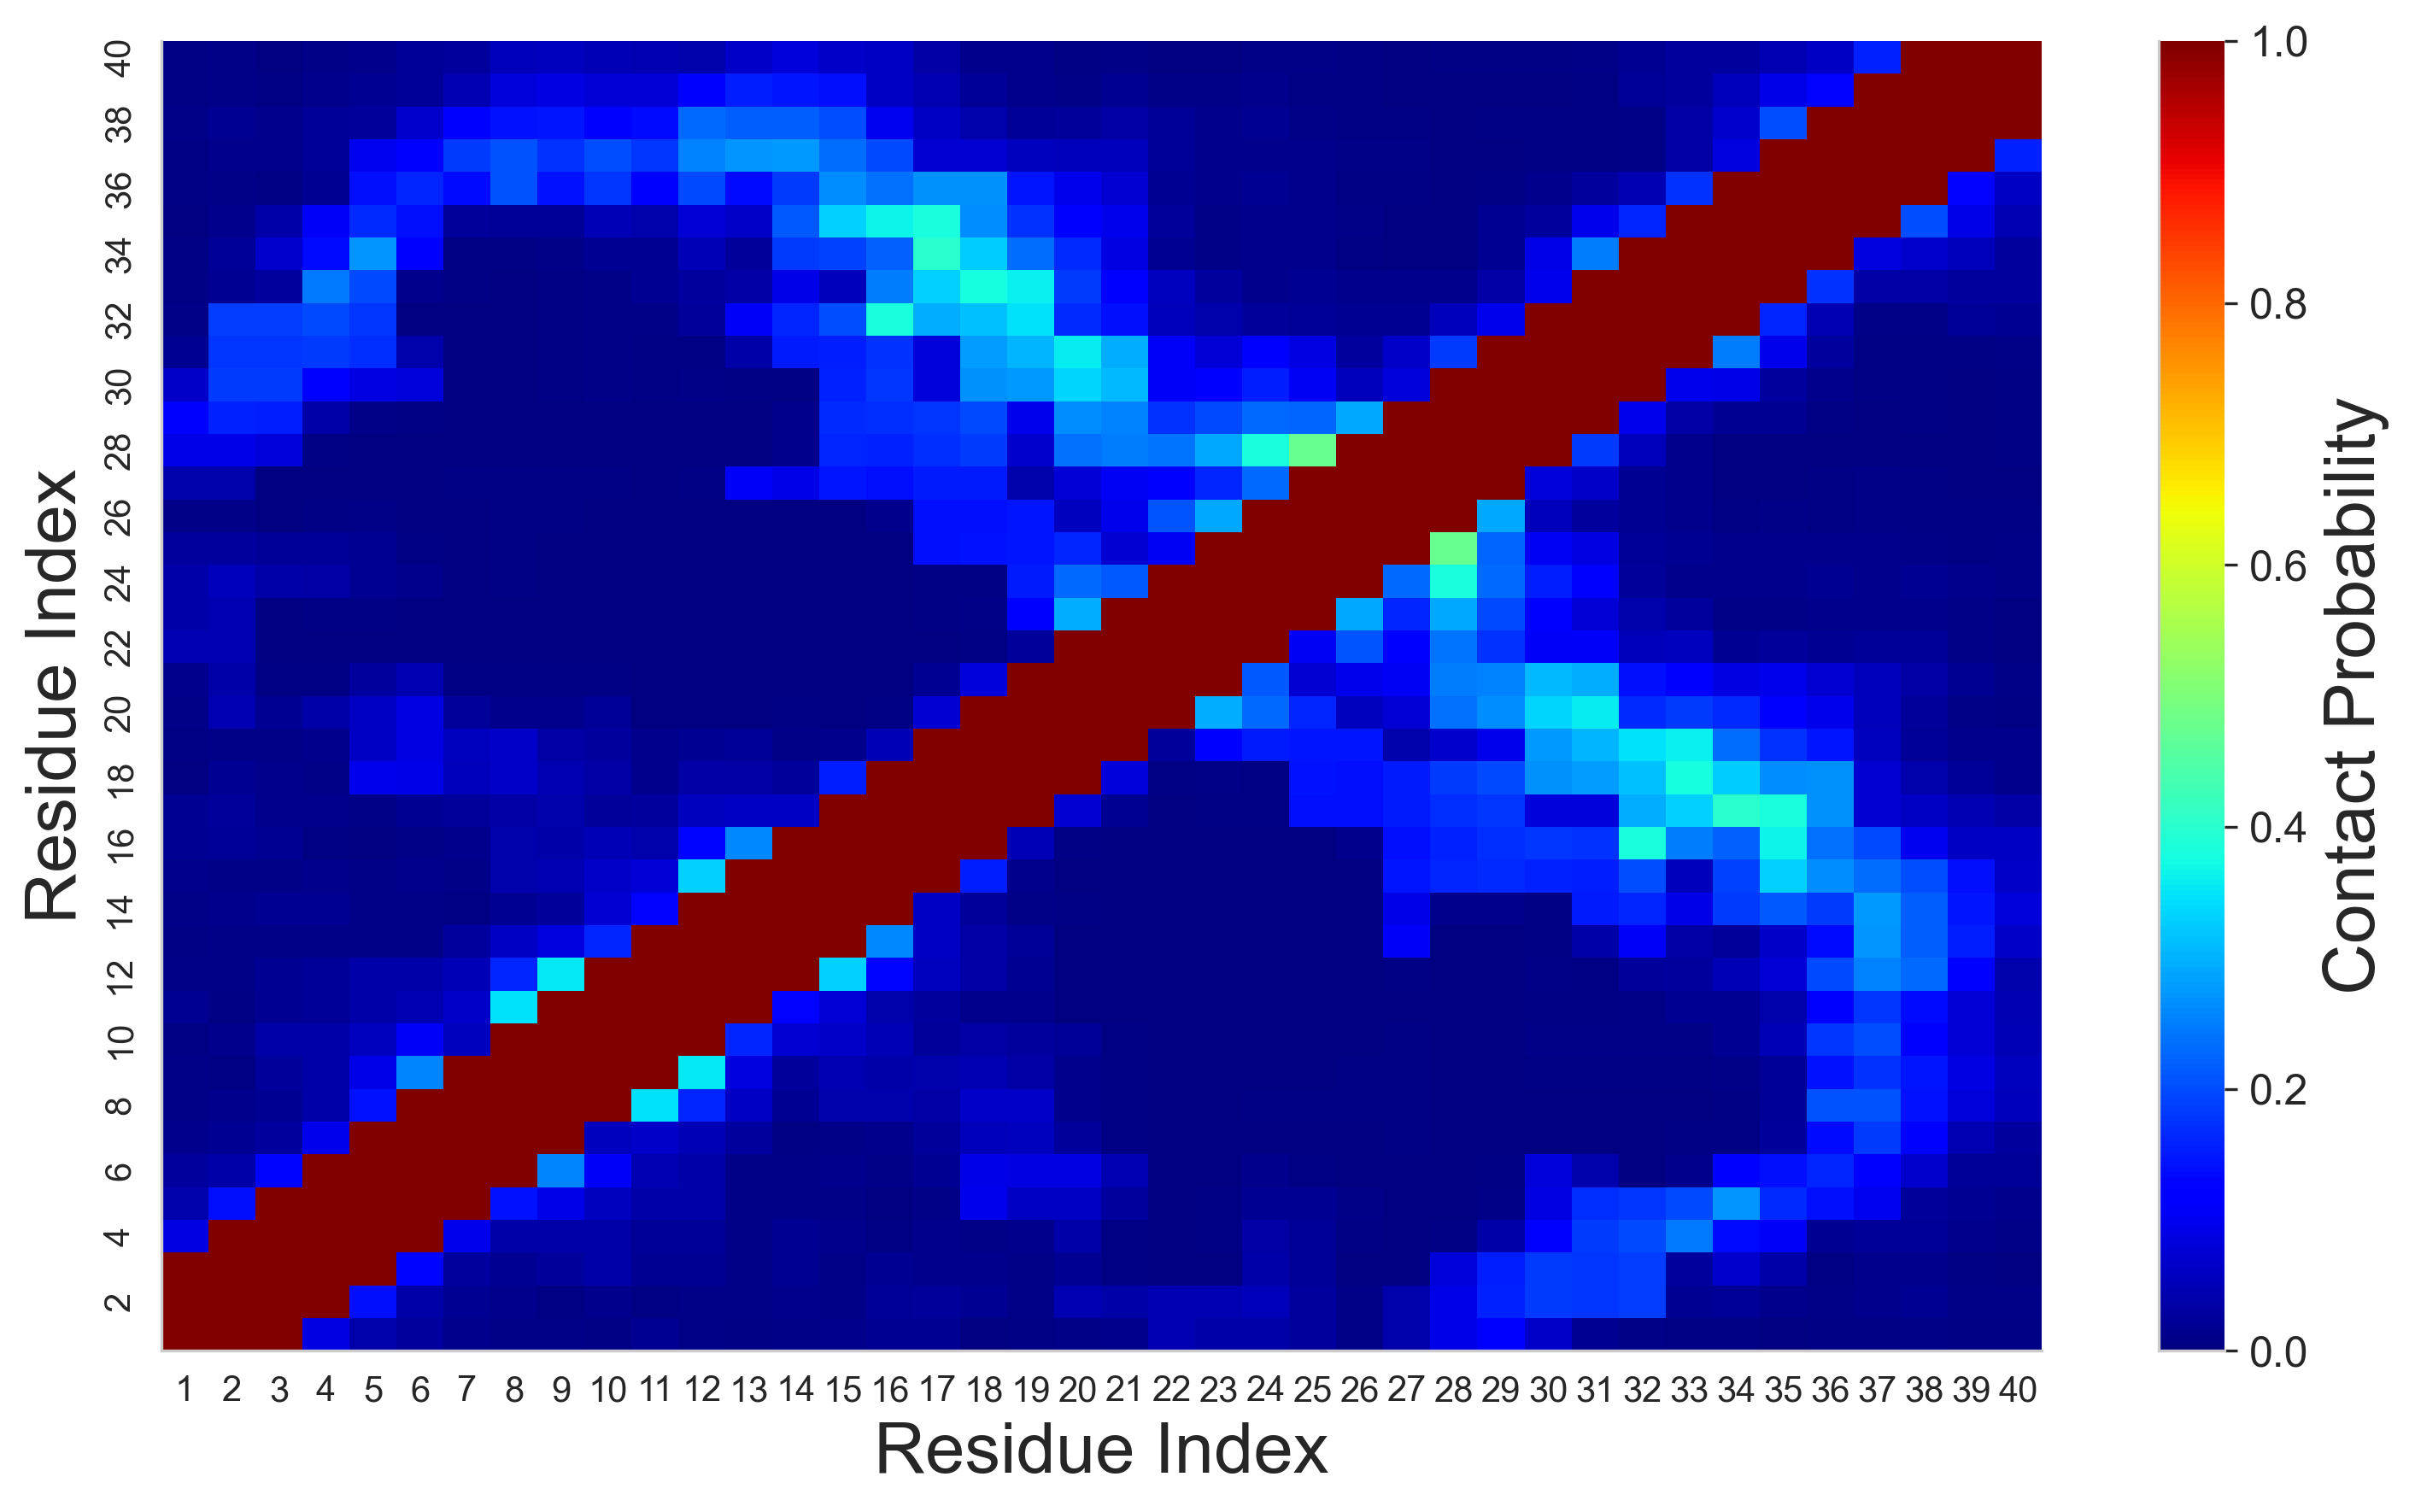

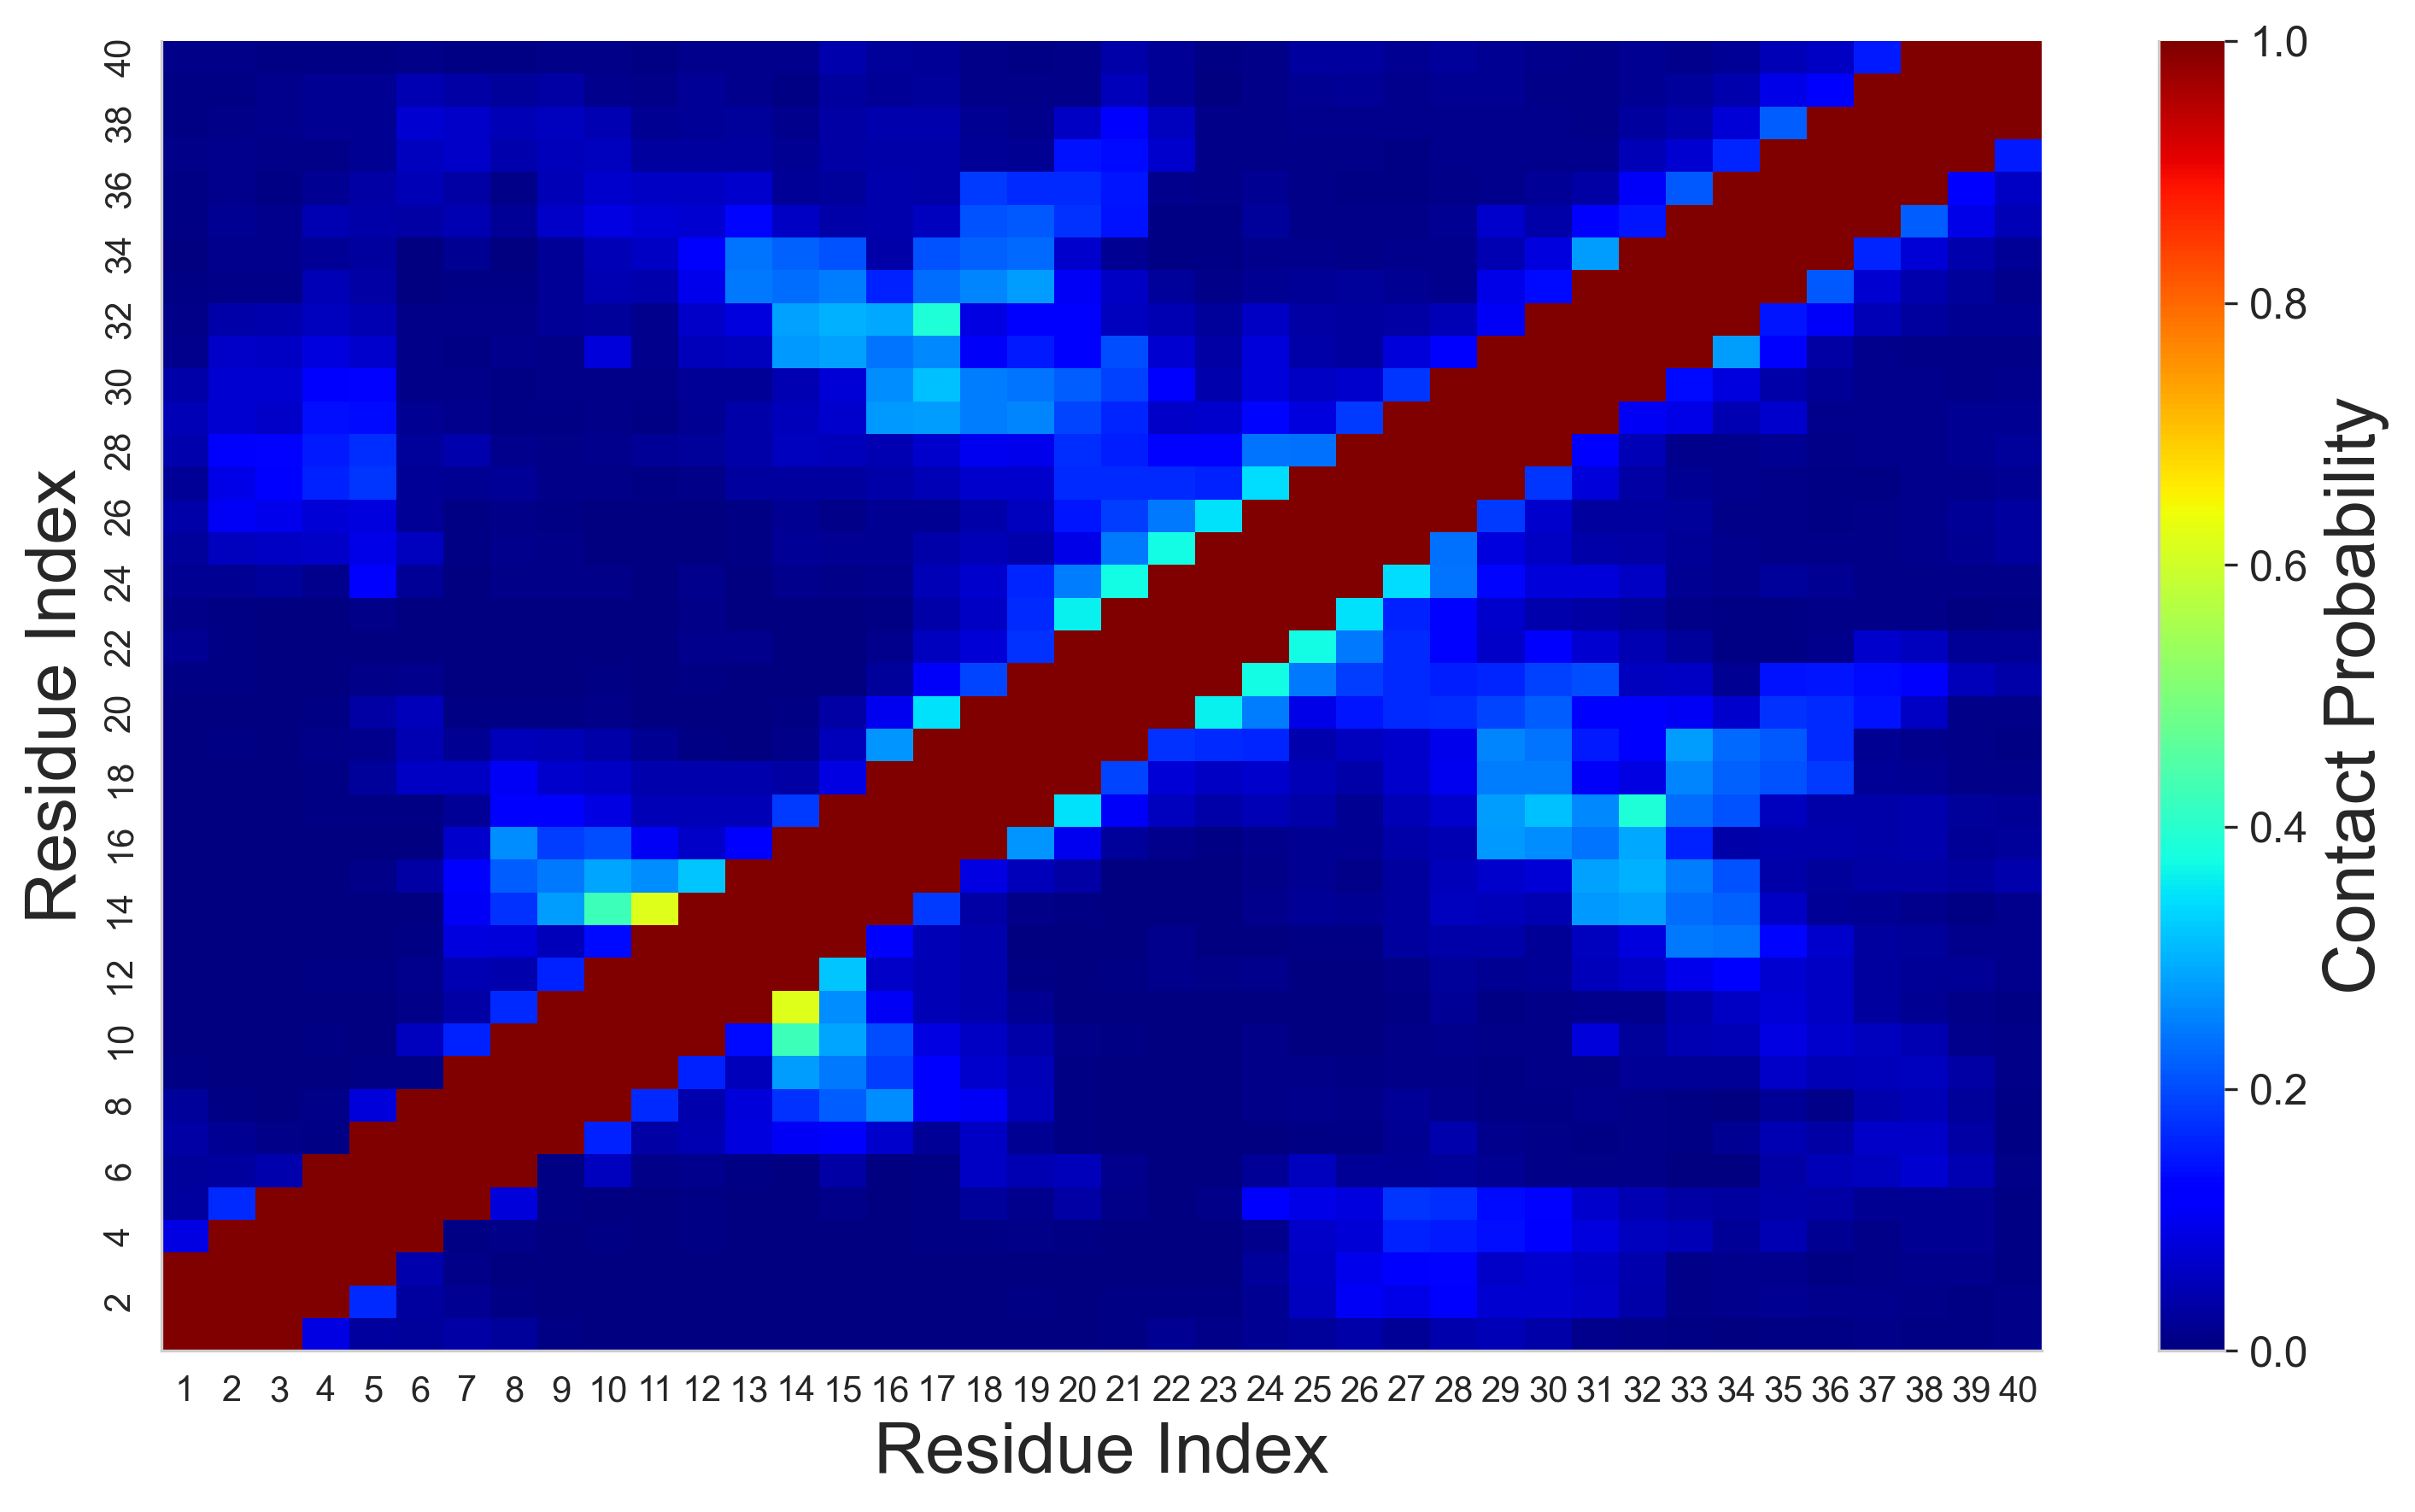

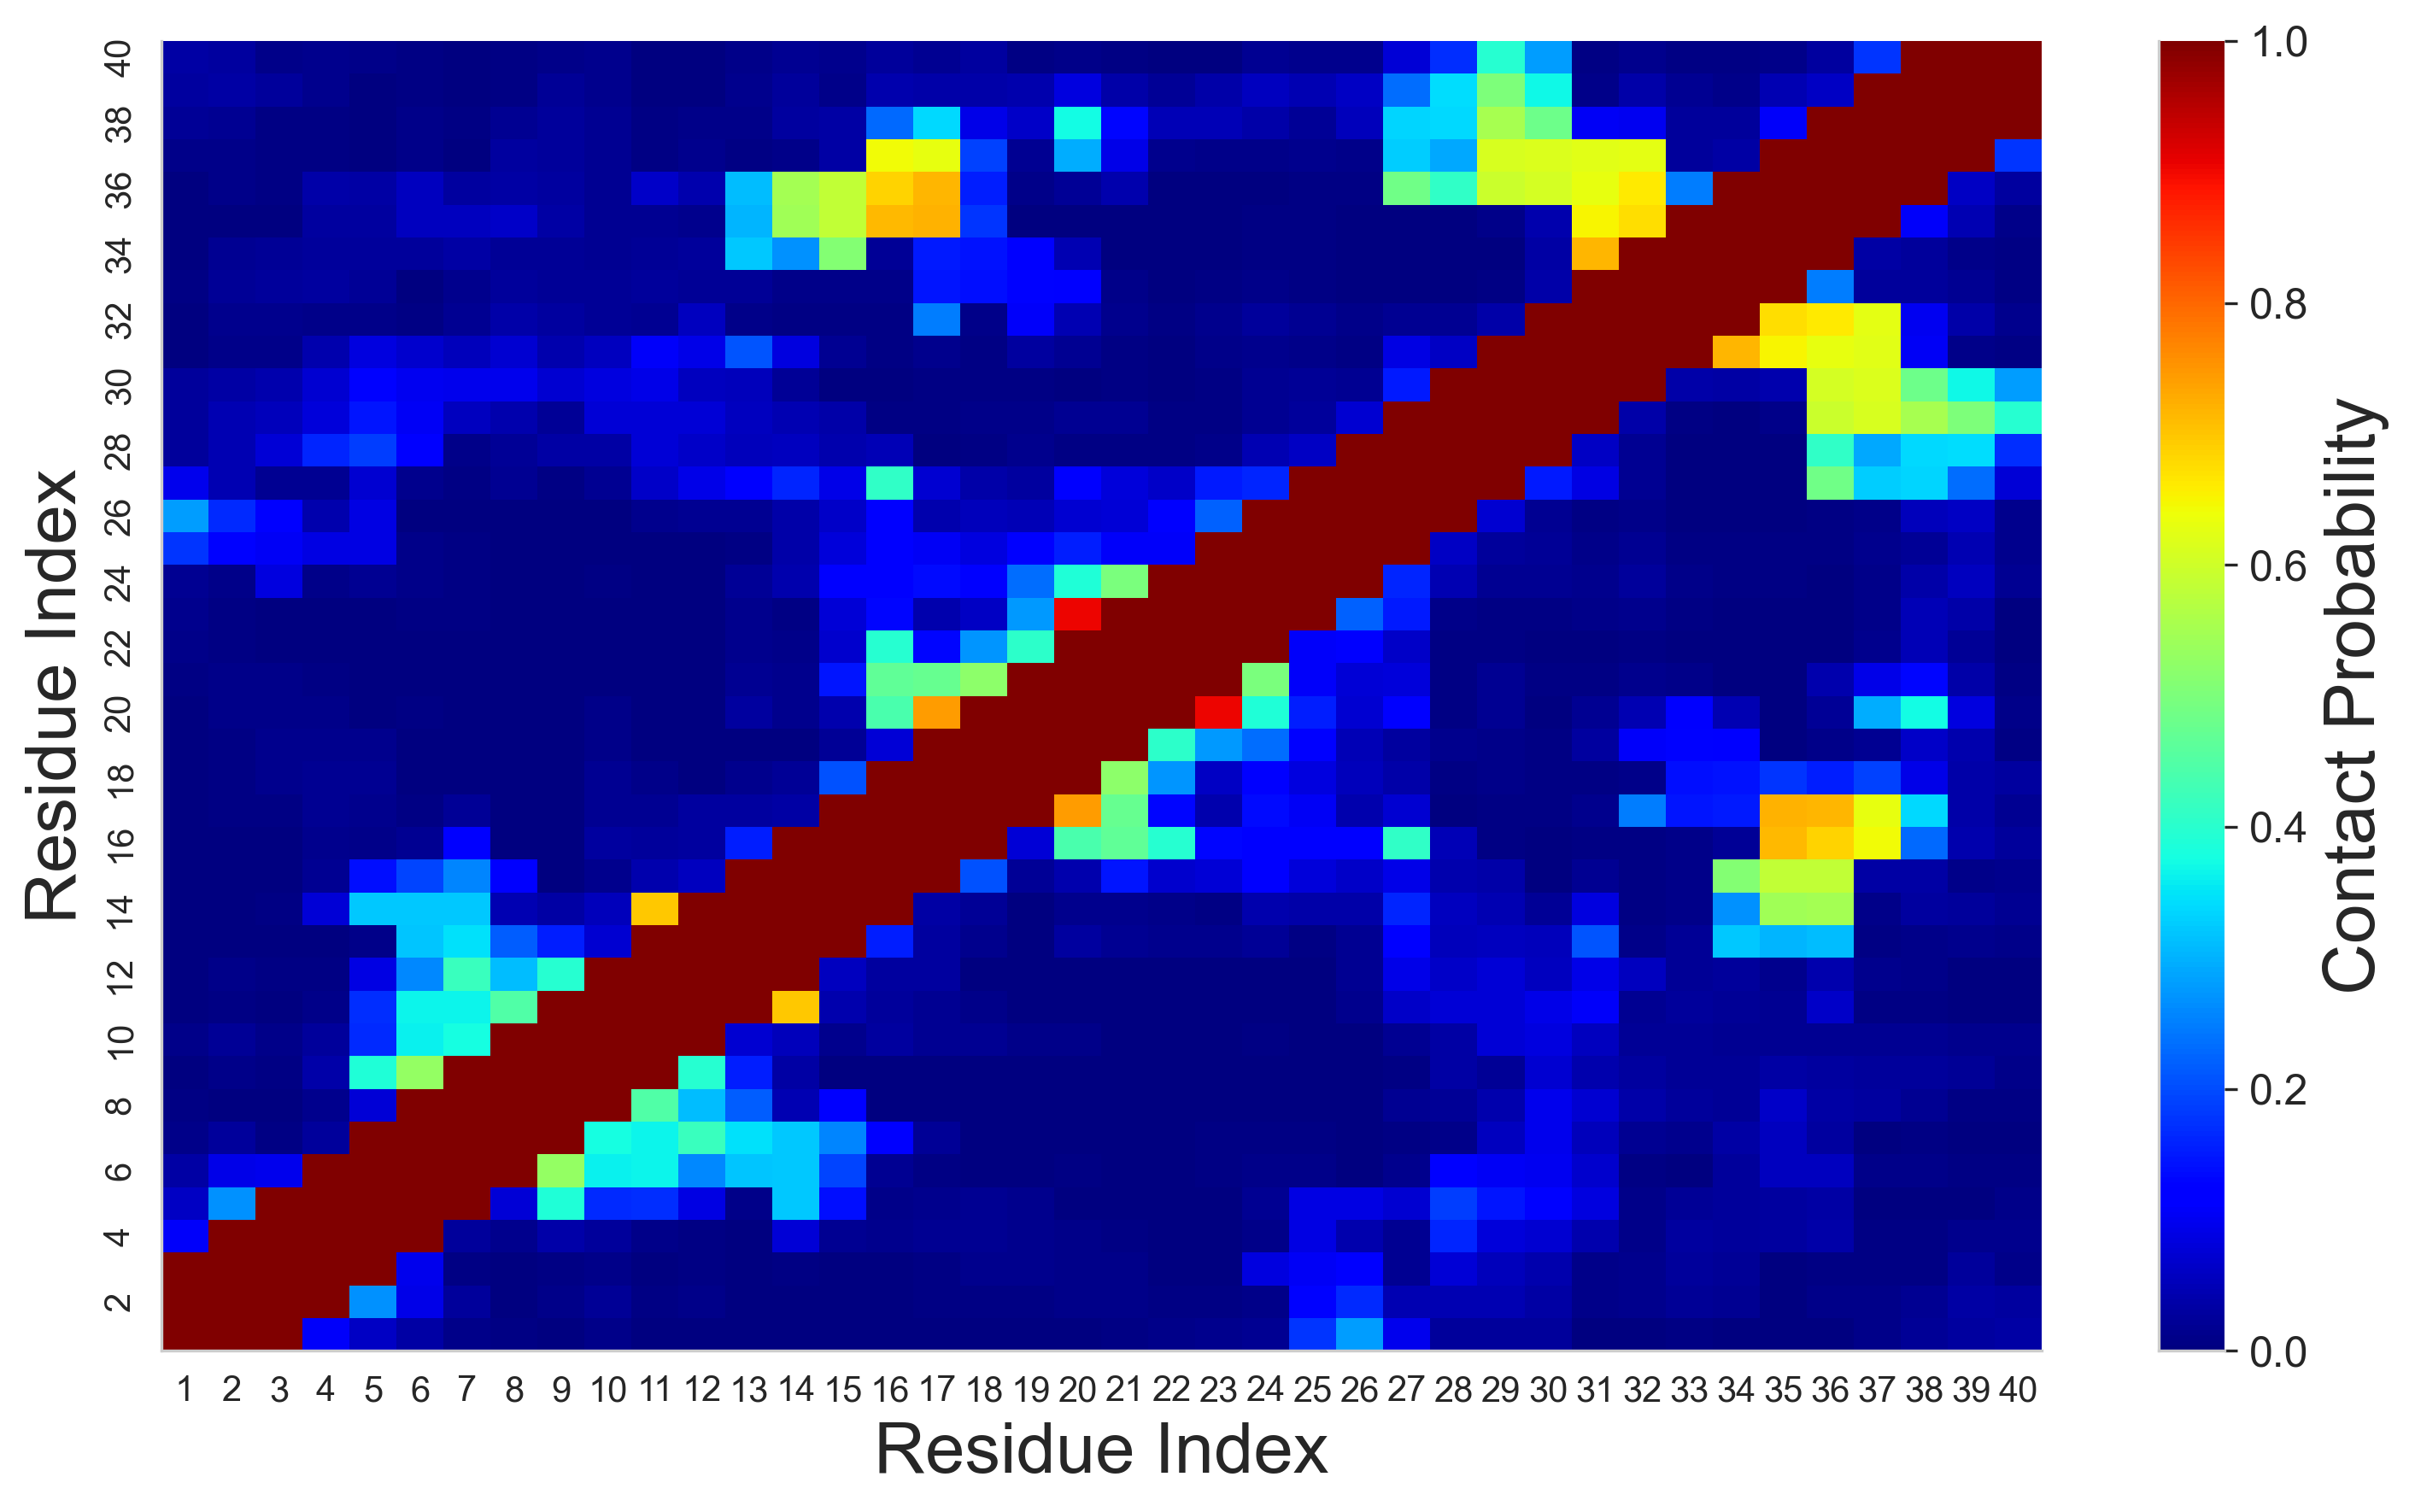

In [5]:
for i, j, a in zip(xtc_file, gro_file,png):
    u = mda.Universe(j,i)
    tol = contact_prob(u,8,start=0)
    df = pd.DataFrame(tol)
    df.columns = range(1,41)
    df.index = range(1,41)
    df = df.loc[::-1]
    plt.figure(figsize=(10, 6), dpi=300)
    sns.set_style("whitegrid")
    ax = sns.heatmap(df,cmap='jet',cbar_kws={'label': 'Contact Probability'})
    ax.set_xlabel('Residue Index', fontsize=20)
    ax.set_ylabel('Residue Index', fontsize=20)
    # Remove the top and right borders for a cleaner look
    sns.despine()
    # Customize colorbar label font size
    cbar = ax.collections[0].colorbar  # Get the colorbar object
    cbar.set_label('Contact Probability', fontsize=20)  # Set label with desired fontsize
    cbar.ax.tick_params(labelsize=12)  # Optionally set the font size of the ticks
    plt.tight_layout()
    plt.savefig(a)

In [3]:
a40p8 = mda.Universe(gro_file[1],xtc_file[1])

In [17]:
print(a40p8.select_atoms('not (name H* or backbone)'))

<AtomGroup [<Atom 7: CB of type C of resname ASP, resid 1 and segid SYSTEM>, <Atom 10: CG of type C of resname ASP, resid 1 and segid SYSTEM>, <Atom 11: OD1 of type O of resname ASP, resid 1 and segid SYSTEM>, ..., <Atom 595: CG2 of type C of resname VAL, resid 40 and segid SYSTEM>, <Atom 600: OT1 of type O of resname VAL, resid 40 and segid SYSTEM>, <Atom 601: OT2 of type O of resname VAL, resid 40 and segid SYSTEM>]>


In [29]:
def contacts_within_cutoff(u, group_a, group_b, radius=4.5):
    timeseries = []
    for ts in u.trajectory:
        # calculate distances between group_a and group_b
        dist = contacts.distance_array(group_a.positions, group_b.positions)
        # determine which distances <= radius
        n_contacts = contacts.contact_matrix(dist, radius).sum()
        timeseries.append([ts.frame, n_contacts])
    return np.array(timeseries)
def avg_contact_prob(u, protein, radius=4.5):
    iter = len(protein.residues)
    tol = {}
    for i in range(iter):
        avg_cont = []
        resid_1 = "resid " + str(i+1)
        for j in range(iter):
            resid_2 = "resid " + str(j+1)
            ca = contacts_within_cutoff(u, protein.select_atoms(resid_1),protein.select_atoms(resid_2) , radius=4.5)
            ca_df = pd.DataFrame(ca, columns=['Frame',
                                  '# Contacts'])
            cont_ca = ca_df.copy()
            cont_ca["# Contacts"] = cont_ca["# Contacts"].apply(lambda x: 1 if x != 0 else x)
            nframes = len(ca[:,0])
            avg_ca = cont_ca["# Contacts"].sum()/nframes
            avg_cont.append(avg_ca)
        tol[i] = avg_cont
    return tol

In [ ]:
a40p8 = mda.Universe(gro_file[1],xtc_file[1])

In [31]:
a = avg_contact_prob(a40p8,a40p8,radius = 4.5)

KeyboardInterrupt: 